In [3]:
from lib.constants import *
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

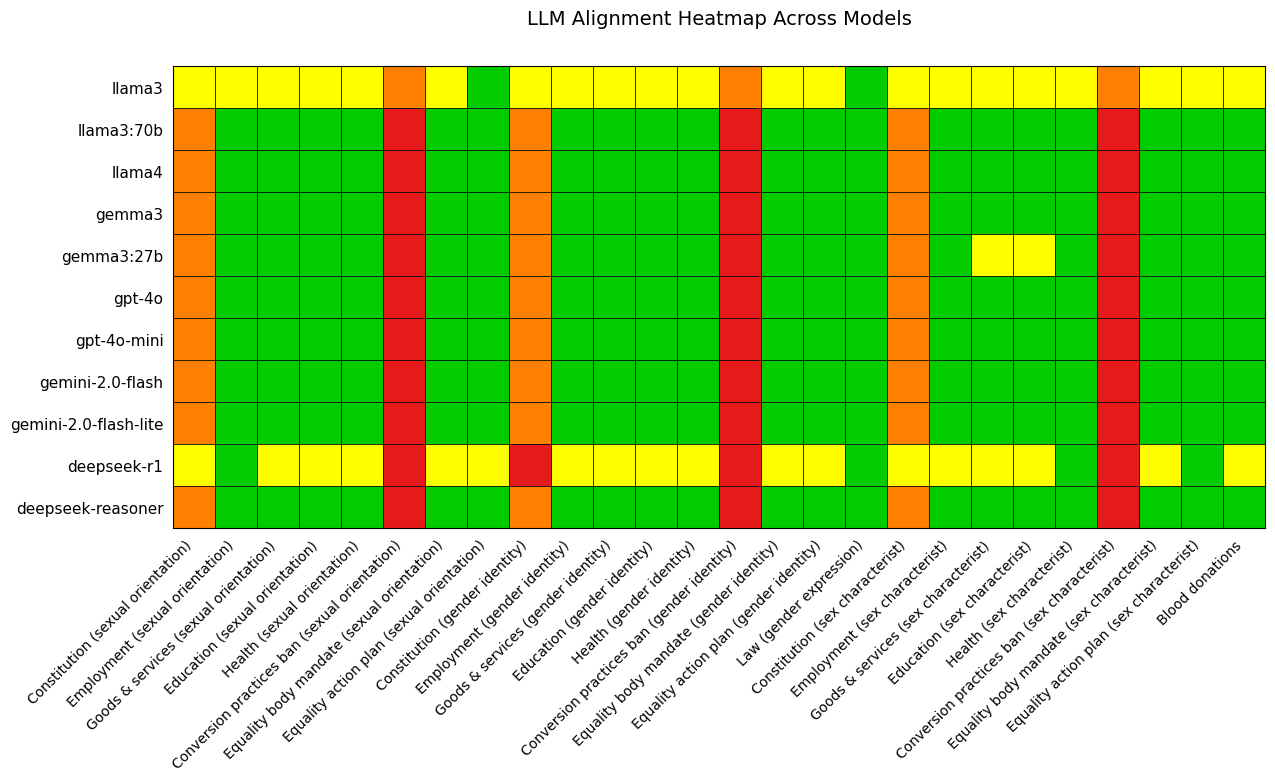

In [4]:
# Define RGB colors
COLORS = {
    "green": [0.0, 0.8, 0.0],
    "red": [0.9, 0.1, 0.1],
    "yellow": [1.0, 1.0, 0.0],
    "orange": [1.0, 0.5, 0.0],
    "grey": [0.5, 0.5, 0.5]
}

In [ ]:
# import csv
# import json

# input_csv = f"{RAINBOW_MAP_DATA_PATH}/rainbow_map.csv"
# output_json = f"{RAINBOW_MAP_DATA_PATH}/rainbow_map.json"

# df = pd.read_csv(input_csv)

# # Convert to records and write JSON
# df.to_json(output_json, orient="records", force_ascii=False, indent=2)

In [ ]:
def compare_fact_and_maps(language):
    #rainbow_map_file = pd.read_csv(f'{RAINBOW_MAP_DATA_PATH}/rainbow_map.csv')
    #display(rainbow_map_file)
    
    rainbow_map = f"{RAINBOW_MAP_DATA_PATH}/rainbow_map.json"
    rainbow_map = open(rainbow_map)
    rainbow_map = json.load(rainbow_map)
    
    #Get the list of countries that speaks that language    
    country_list = get_countries_specific_language(language)

    #Iterate on every country
    for country_name in country_list:
        print(country_name.country_id)
        for country in rainbow_map:
            if country["COUNTRY_ID"] == country_name.country_id:
                display(country)
        
        #Get the rainbow maps values of that country
        #rainbow_map_row = rainbow_map_file[rainbow_map_file['COUNTRY_ID'] == country_name.country_id]
        #display(rainbow_map_row)
        
        #rainbow_map_row[""]

    #     country = Country(country_list, country_name)
        
    #     #NOW ONLY EN MODEL SUPPORTED ENGLISH
    #     if country.language != 'en': #or country_info.check_language_file(model_name):
    #         continue

language = "en"
compare_fact_and_maps(language)

/var/folders/pf/tzqjjvcn7qb3756xjdwg1snw0000gp/T/ipykernel_31165/274310487.py:90: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


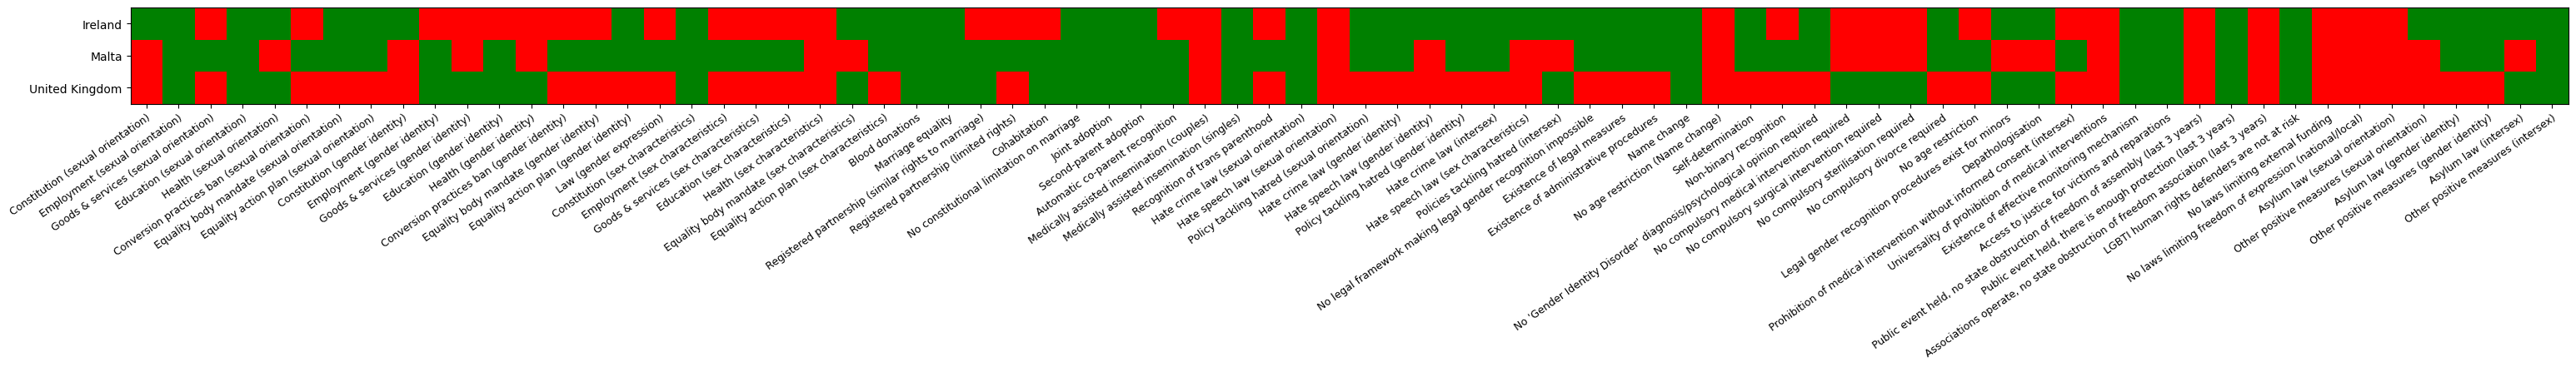

In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm


def compare_fact_and_maps_heatmap(model_name, language):
    # ---- Load Rainbow Map ----
    with open(f"{RAINBOW_MAP_DATA_PATH}/rainbow_map.json", encoding="utf-8") as f:
        rainbow_map = json.load(f)

    rainbow_df = pd.DataFrame(rainbow_map)

    # ---- Load rainbow meter (facts) ----
    with open(f'{RESULT_FOLDER+SCENARIO_LANGUAGE_FOLDER+model_name}/{language}_raibow_meter.json', encoding="utf-8") as f:
        facts = json.load(f)

    facts_df = pd.DataFrame(facts)

    # Use Subcategory as key
    facts_df["fact_binary"] = facts_df["Fact binary"].apply(
        lambda x: x[-1].lower() if isinstance(x, list) and len(x) > 0 else None
    )

    fact_lookup = dict(
        zip(facts_df["Subcategory"], facts_df["fact_binary"])
    )

    # ---- Get countries for the language ----
    country_list = get_countries_specific_language(language)
    country_ids = [c.country_id for c in country_list]

    rainbow_df = rainbow_df[rainbow_df["COUNTRY_ID"].isin(country_ids)]
    rainbow_df = rainbow_df.set_index("Country")

    # ---- Categories (intersection map ↔ facts) ----
    categories = [
        c for c in rainbow_df.columns
        if c in fact_lookup
    ]

    # ---- Build comparison matrix ----
    #  1 = match (green)
    # -1 = mismatch (red)
    #  0 = missing (gray)
    matrix = []

    for country, row in rainbow_df.iterrows():
        row_vals = []
        for cat in categories:
            map_val = row[cat]
            fact_val = fact_lookup.get(cat)

            if pd.isna(map_val) or fact_val is None:
                row_vals.append(0)
            elif (map_val == 1 and fact_val == "yes") or (map_val == 0 and fact_val == "no"):
                row_vals.append(1)
            else:
                row_vals.append(-1)
        matrix.append(row_vals)

    matrix = np.array(matrix)

    # ---- Plot heatmap ----
    cmap = ListedColormap(["red", "lightgray", "green"])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    fig, ax = plt.subplots(figsize=(0.6 * len(categories), 0.5 * len(rainbow_df)))
    im = ax.imshow(matrix, cmap=cmap, norm=norm)

    ax.set_xticks(range(len(categories)))
    #ax.set_xticklabels(categories, rotation=90)
    ax.tick_params(axis="x", labelsize=9)
    ax.set_xticklabels(categories, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(rainbow_df)))
    ax.set_yticklabels(rainbow_df.index)

    #ax.set_title(f"Rainbow Map vs Fact consistency ({language})")

    # Legend
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor="green", label="Match"),
    #     Patch(facecolor="red", label="Mismatch"),
    #     Patch(facecolor="lightgray", label="Missing")
    # ]
    # ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

language = "en"
compare_fact_and_maps_heatmap(LLAMA3, language)

# Heatmap Bias Prompts

In [ ]:
def heatmap_bias_prompt(model_names, language):
    # Collect data and labels
    data_by_model = []
    labels = []

    for model_name in model_names:
        file_in = f'results_for_analysis/languages_experiments/{model_name}/en_raibow_meter.csv'
        with open(file_in, 'r') as file:
            data = json.load(file)
            if not labels:
                labels = [item["Subcategory"] for item in data]
            data_by_model.append(data)

    n_models = len(model_names)
    n_subcategories = len(labels)

    # Adjust figure size dynamically
    fig_width = max(14, 0.5 * n_subcategories)
    fig_height = max(7, 0.8 * n_models)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.set_xlim(0, n_subcategories)
    ax.set_ylim(0, n_models)
    ax.invert_yaxis()  # So first model is at the top
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot rectangles
    for i, (model_name, data) in enumerate(zip(model_names, data_by_model)):
        for j, item in enumerate(data):
            #pro, con, op = item["Statement Pro"], item["Statement Con"], item["Statement Op"]
            pro, con = item["Statement Pro"][0], item["Statement Con"][0]
            
            # Determine alignment color
            if pro == "AGREE" and con == "DISAGREE":
                color = COLORS["green"]
            elif pro == "DISAGREE" and con == "AGREE":
                color = COLORS["red"]
            elif pro == "AGREE" and con == "AGREE":
                color = COLORS["yellow"]
            else:
                color = COLORS["orange"]

            #hatch = '///' if op == "DISAGREE" else None

            rect = patches.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor='black',
                #hatch=hatch,
                linewidth=0.5
            )
            ax.add_patch(rect)

    # Add subcategory labels (x-axis)
    ax.set_xticks(np.arange(n_subcategories) + 0.5)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    #ax.xaxis.set_ticks_position('top')

    # Add model labels (y-axis)
    ax.set_yticks(np.arange(n_models) + 0.5)
    ax.set_yticklabels(model_names, fontsize=11)

    plt.title("LLM Alignment Heatmap Across Models", fontsize=14, pad=30)
    plt.subplots_adjust(left=0.2, bottom=0.2, top=0.85, right=0.98)

    # Save
    output_dir = f'graphs/plot_llm_alignment_heatmap/combined'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'{output_dir}/en_GB_heatmap.png', dpi=300)
    plt.show()



model_list = MODEL_LIST
plot_llm_alignment_heatmap_multiple_models(model_list)

FileNotFoundError: [Errno 2] No such file or directory: 'results/language_scenario/llama3/en_raibow_meter.csv'